# OCPP 1.6 ML-Based Intrusion Detection System

This notebook builds a Machine Learning-based IDS using the **Federated OCPP 1.6 Intrusion Detection Dataset**.

**Dataset source:** [Zenodo](https://zenodo.org/records/14887131) | [IEEE DataPort](https://ieee-dataport.org/documents/federated-ocpp-16-intrusion-detection-dataset)

**Files used:**
- `Balanced_OCPP16_APP_Layer` (primary — OCPP application-layer features)
- `Balanced_OCPP16_TCP-IP_Layer` (optional — TCP/IP flow features for fusion)

**Attacks covered:**
| # | Attack | Layer Best Detected |
|---|--------|--------------------|
| 1 | Charging Profile Manipulation | APP |
| 2 | Denial of Charge | APP |
| 3 | Heartbeat Flooding DoS | TCP/IP + APP |
| 4 | Unauthorized Access | APP |

**Pipeline overview:**
1. Install dependencies
2. Load & inspect data
3. Preprocessing & feature engineering
4. Feature selection
5. Train multiple ML models
6. Evaluate & compare
7. (Optional) Fuse APP + TCP/IP layers
8. Hyperparameter tuning
9. Save best model

## Install Dependencies

In [ ]:
!pip install -q xgboost lightgbm imbalanced-learn scikit-learn matplotlib seaborn pandas numpy joblib

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

## Load the Dataset
**Source:**
https://zenodo.org/records/14887131


In [ ]:
# --- Option A: Mount Google Drive ---
# Uncomment if your files are in Google Drive
from google.colab import drive
drive.mount('/content/drive')

TCP_TRAIN_PATH = "/content/drive/MyDrive/Thesis/Balanced_OCPP16_TCP-IP_Layer/Combined/Train.csv"
TCP_TEST_PATH = "/content/drive/MyDrive/Thesis/Balanced_OCPP16_TCP-IP_Layer/Combined/Test.csv"
APP_TRAIN_PATH = '/content/drive/MyDrive/Thesis/Balanced_OCPP16_APP_Layer/Combined/Train.csv'
APP_TEST_PATH = '/content/drive/MyDrive/Thesis/Balanced_OCPP16_APP_Layer/Combined/Test.csv'
print('Paths configured')

Mounted at /content/drive
Paths configured


In [ ]:
# Load APP Layer — using the pre-split train.csv and test.csv
df_app_train = pd.read_csv(APP_TRAIN_PATH)
df_app_test  = pd.read_csv(APP_TEST_PATH)

print(f'APP Layer Train shape: {df_app_train.shape}')
print(f'APP Layer Test shape:  {df_app_test.shape}')
print(f'\nColumns: {list(df_app_train.columns)}')
df_app_train.head()

APP Layer Train shape: (3020, 55)
APP Layer Test shape:  (1295, 55)

Columns: ['flow_id', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'total_flow_packets', 'total_fw_packets', 'total_bw_packets', 'flow_duration', 'flow_down_up_ratio', 'flow_total_SYN_flag', 'flow_total_RST_flag', 'flow_total_PSH_flag', 'flow_total_ACK_flag', 'flow_total_URG_flag', 'flow_total_CWE_flag', 'flow_total_ECE_flag', 'flow_total_FIN_flag', 'flow_start_timestamp', 'flow_end_timestamp', 'flow_total_http_get_packets', 'flow_total_http_2xx_packets', 'flow_total_http_4xx_packets', 'flow_total_http_5xx_packets', 'flow_websocket_packts_per_second', 'fw_websocket_packts_per_second', 'bw_websocket_packts_per_second', 'flow_websocket_bytes_per_second', 'fw_websocket_bytes_per_second', 'bw_websocket_bytes_per_second', 'flow_total_websocket_ping_packets', 'flow_total_websocket_pong_packets', 'flow_total_websocket_close_packets', 'flow_total_websocket_data_messages', 'flow_total_ocpp16_heartbeat_packets', 'flow_total_ocpp1

,flow_id,src_ip,dst_ip,src_port,dst_port,total_flow_packets,total_fw_packets,total_bw_packets,flow_duration,flow_down_up_ratio,...,flow_avg_ocpp16_setchargingprofile_minchargingrate,flow_min_ocpp16_setchargingprofile_minchargingrate,flow_max_ocpp16_setchargingprofile_minchargingrate,flow_total_ocpp16_metervalues,flow_min_ocpp16_metervalues_soc,flow_max_ocpp16_metervalues_soc,flow_avg_ocpp16_metervalues_wh_diff,flow_max_ocpp16_metervalues_wh_diff,flow_min_ocpp16_metervalues_wh_diff,label
0,192.168.21.128-192.168.21.70-33924-80,192.168.21.128,192.168.21.70,33924,80,124,61,63,109681274.0,1.032787,...,0.0,0,0,8,0.0,0.0,0.0,0,0,cyberattack_ocpp16_doc_idtag
1,192.168.21.225-192.168.21.70-43060-80,192.168.21.225,192.168.21.70,43060,80,11,6,5,10878.0,0.833333,...,0.0,0,0,0,0.0,0.0,0.0,0,0,cyberattack_ocpp16_unauthorized_access
2,192.168.21.225-192.168.21.70-54402-80,192.168.21.225,192.168.21.70,54402,80,11,6,5,17714.0,0.833333,...,0.0,0,0,0,0.0,0.0,0.0,0,0,cyberattack_ocpp16_unauthorized_access
3,192.168.21.128-192.168.21.70-55498-80,192.168.21.128,192.168.21.70,55498,80,115,52,63,97371003.0,1.211538,...,0.0,0,0,8,0.0,0.0,0.0,0,0,cyberattack_ocpp16_doc_idtag
4,192.168.21.225-192.168.21.70-57601-80,192.168.21.225,192.168.21.70,57601,80,11,6,5,12521.0,0.833333,...,0.0,0,0,0,0.0,0.0,0.0,0,0,cyberattack_ocpp16_unauthorized_access


Class distribution — Train:
label
cyberattack_ocpp16_doc_idtag                 604
cyberattack_ocpp16_unauthorized_access       604
cyberattack_ocpp16_dos_flooding_heartbeat    604
cyberattack_ocpp16_fdi_chargingprofile       604
normal                                       604
Name: count, dtype: int64

Class distribution — Test:
label
cyberattack_ocpp16_dos_flooding_heartbeat    259
cyberattack_ocpp16_fdi_chargingprofile       259
cyberattack_ocpp16_unauthorized_access       259
normal                                       259
cyberattack_ocpp16_doc_idtag                 259
Name: count, dtype: int64


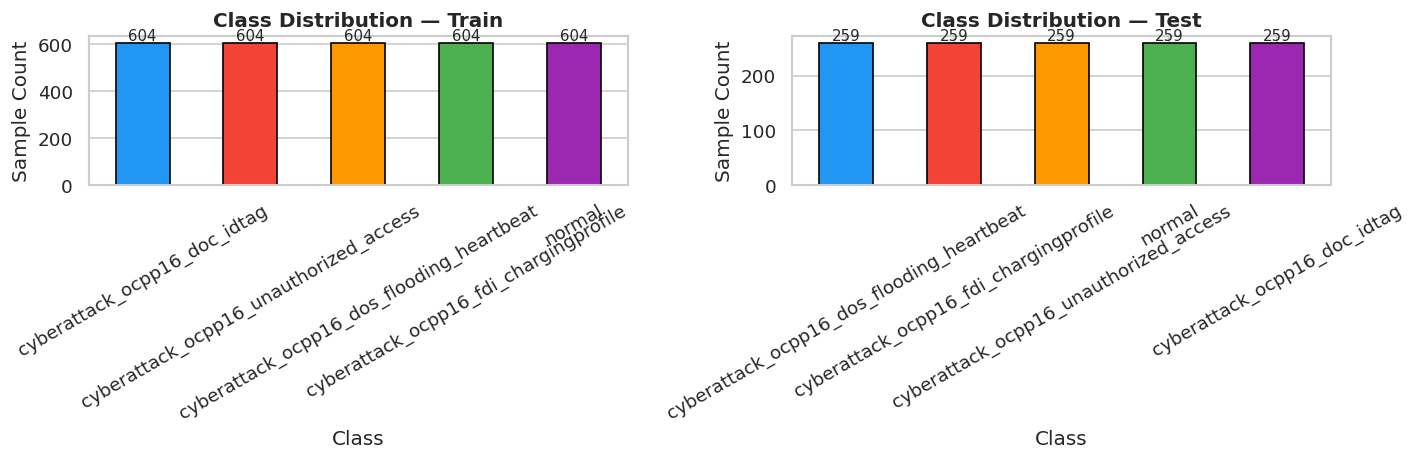

In [ ]:
LABEL_COL = 'label'

print(f'Class distribution — Train:')
print(df_app_train[LABEL_COL].value_counts())
print(f'\nClass distribution — Test:')
print(df_app_test[LABEL_COL].value_counts())

# Visualize class distribution side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#2196F3', '#F44336', '#FF9800', '#4CAF50', '#9C27B0']

for ax, (df_split, title) in zip(axes, [(df_app_train, 'Train'), (df_app_test, 'Test')]):
    counts = df_split[LABEL_COL].value_counts()
    counts.plot(kind='bar', ax=ax, color=colors[:len(counts)], edgecolor='black')
    ax.set_title(f'Class Distribution — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel('Sample Count')
    ax.tick_params(axis='x', rotation=30)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## Preprocessing

Following the dataset paper recommendations:
1. Drop non-predictive features (IPs, flow IDs, timestamps)
2. Handle infinite values and NaNs
3. Label encode the target
4. Standard scale features

> **No train/test split needed** — the dataset already provides separate `train.csv` and `test.csv` files. We use them directly, which ensures our evaluation matches the original paper's protocol.

In [ ]:
# Check for nulls and data types (on training set)
print('=== Data Types ===')
print(df_app_train.dtypes.value_counts())

print(f'\n=== Null/Inf Summary (Train) ===')
null_counts = df_app_train.isnull().sum()
inf_counts = df_app_train.isin([np.inf, -np.inf]).sum()
print(f'Columns with nulls:  {(null_counts > 0).sum()}')
print(f'Columns with inf:    {(inf_counts > 0).sum()}')

# Show top null columns if any
top_nulls = null_counts[null_counts > 0].sort_values(ascending=False).head(10)
if not top_nulls.empty:
    print('\nTop columns with nulls:')
    print(top_nulls)

=== Data Types ===
int64      36
float64    15
object      4
Name: count, dtype: int64

=== Null/Inf Summary (Train) ===
Columns with nulls:  0
Columns with inf:    0


In [ ]:
def preprocess_split(df_train, df_test, label_col, drop_cols=None):
    """
    Preprocesses pre-split train and test dataframes.
    IMPORTANT: LabelEncoder and StandardScaler are fit ONLY on train, then applied to test.
    Returns: X_train, X_test, y_train, y_test, label_encoder, feature_names
    """
    df_tr = df_train.copy()
    df_te = df_test.copy()

    # 1. Drop non-predictive columns
    default_drop = ['flow_id', 'src_ip', 'dst_ip',
                'flow_start_timestamp', 'flow_end_timestamp']
    if drop_cols:
        default_drop += drop_cols
    cols_to_drop = [c for c in default_drop if c in df_tr.columns]
    df_tr.drop(columns=cols_to_drop, inplace=True)
    df_te.drop(columns=[c for c in cols_to_drop if c in df_te.columns], inplace=True)
    print(f'  Dropped {len(cols_to_drop)} non-predictive columns: {cols_to_drop}')

    # 2. Handle inf and NaN
    for df in [df_tr, df_te]:
        df.replace([np.inf, -np.inf], np.nan, inplace=True)
    before_tr, before_te = len(df_tr), len(df_te)
    df_tr.dropna(inplace=True)
    df_te.dropna(inplace=True)
    print(f'  Removed {before_tr - len(df_tr)} train rows and {before_te - len(df_te)} test rows with NaN/Inf')

    # 3. Encode labels — fit on train only
    le = LabelEncoder()
    y_train = le.fit_transform(df_tr[label_col])
    y_test  = le.transform(df_te[label_col])   # reuse same encoding
    print(f'  Label classes: {list(le.classes_)}')

    # 4. Separate features
    X_train = df_tr.drop(columns=[label_col]).select_dtypes(include=[np.number])
    X_test  = df_te.drop(columns=[label_col]).select_dtypes(include=[np.number])

    # Align columns (in case test has extra/missing cols)
    X_test = X_test[X_train.columns]

    print(f'  Feature count:  {X_train.shape[1]}')
    print(f'  Train samples:  {X_train.shape[0]}')
    print(f'  Test samples:   {X_test.shape[0]}')

    return X_train, X_test, pd.Series(y_train), pd.Series(y_test), le, list(X_train.columns)


print('Preprocessing APP Layer (train + test)...')
X_train, X_test, y_train, y_test, le_app, feature_names = preprocess_split(df_app_train, df_app_test, LABEL_COL)

print(f'\nPreprocessing complete.')
print(f'Label mapping: { {cls: i for i, cls in enumerate(le_app.classes_)} }')

Preprocessing APP Layer (train + test)...
  Dropped 5 non-predictive columns: ['flow_id', 'src_ip', 'dst_ip', 'flow_start_timestamp', 'flow_end_timestamp']
  Removed 0 train rows and 0 test rows with NaN/Inf
  Label classes: ['cyberattack_ocpp16_doc_idtag', 'cyberattack_ocpp16_dos_flooding_heartbeat', 'cyberattack_ocpp16_fdi_chargingprofile', 'cyberattack_ocpp16_unauthorized_access', 'normal']
  Feature count:  49
  Train samples:  3020
  Test samples:   1295

Preprocessing complete.
Label mapping: {'cyberattack_ocpp16_doc_idtag': 0, 'cyberattack_ocpp16_dos_flooding_heartbeat': 1, 'cyberattack_ocpp16_fdi_chargingprofile': 2, 'cyberattack_ocpp16_unauthorized_access': 3, 'normal': 4}


In [ ]:
# No splitting needed — train.csv and test.csv are already the correct splits.
# We only need to apply StandardScaler (fit on train, transform both).

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)         # apply same scale to test

print(f'Train size: {X_train_scaled.shape}')
print(f'Test size:  {X_test_scaled.shape}')

# Verify class balance
train_dist = y_train.value_counts().sort_index()
test_dist  = y_test.value_counts().sort_index()
split_df = pd.DataFrame({'Train': train_dist, 'Test': test_dist})
split_df.index = le_app.classes_
print(f'\nClass distribution per split:')
print(split_df)

Train size: (3020, 49)
Test size:  (1295, 49)

Class distribution per split:
                                           Train  Test
cyberattack_ocpp16_doc_idtag                 604   259
cyberattack_ocpp16_dos_flooding_heartbeat    604   259
cyberattack_ocpp16_fdi_chargingprofile       604   259
cyberattack_ocpp16_unauthorized_access       604   259
normal                                       604   259


## Step 5 — Feature Selection

Use a Random Forest to rank feature importances and optionally select the top-N most predictive features.

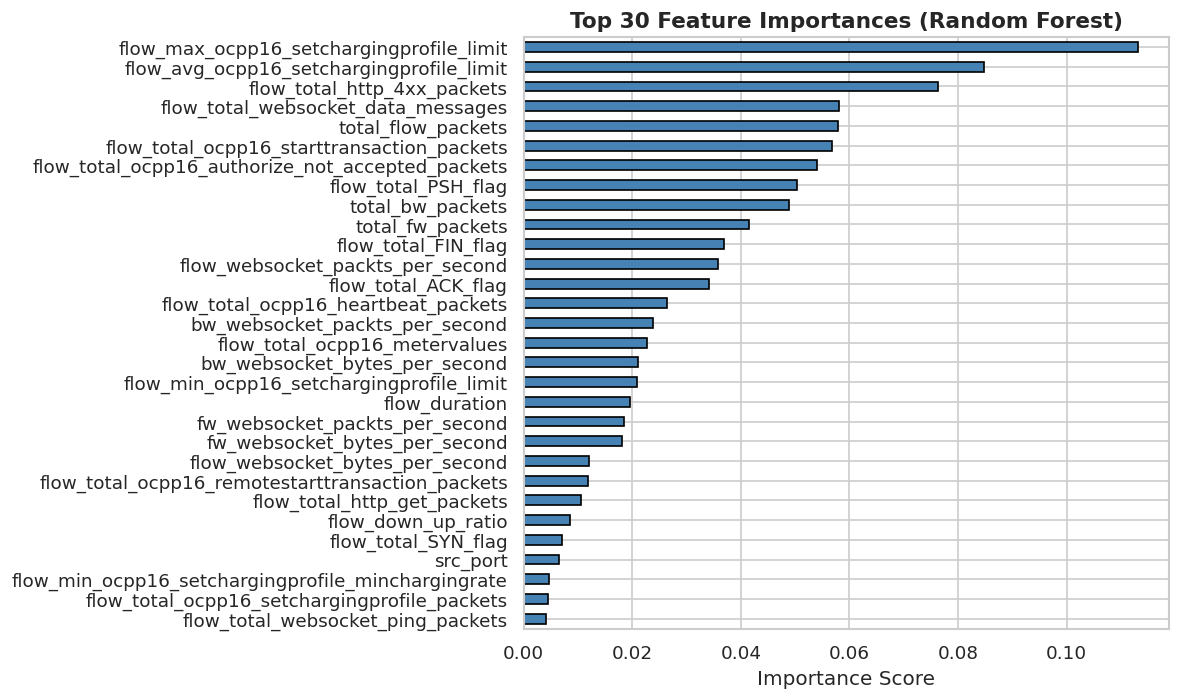


Top 30 features:
flow_max_ocpp16_setchargingprofile_limit              0.113166
flow_avg_ocpp16_setchargingprofile_limit              0.084823
flow_total_http_4xx_packets                           0.076399
flow_total_websocket_data_messages                    0.058161
total_flow_packets                                    0.057844
flow_total_ocpp16_starttransaction_packets            0.056860
flow_total_ocpp16_authorize_not_accepted_packets      0.054105
flow_total_PSH_flag                                   0.050273
total_bw_packets                                      0.048863
total_fw_packets                                      0.041517
flow_total_FIN_flag                                   0.036950
flow_websocket_packts_per_second                      0.035701
flow_total_ACK_flag                                   0.034209
flow_total_ocpp16_heartbeat_packets                   0.026348
bw_websocket_packts_per_second                        0.023748
flow_total_ocpp16_metervalues        

In [ ]:
TOP_N_FEATURES = 30  # Adjust as needed (None = use all)

# Quick RF for feature importance
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train_scaled, y_train)

importances = pd.Series(rf_selector.feature_importances_, index=X_train.columns)
importances_sorted = importances.sort_values(ascending=False)

# Plot top features
fig, ax = plt.subplots(figsize=(10, 6))
top_imp = importances_sorted.head(TOP_N_FEATURES)
top_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.invert_yaxis()
ax.set_title(f'Top {TOP_N_FEATURES} Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(f'\nTop {TOP_N_FEATURES} features:')
print(top_imp.to_string())

In [ ]:
# Apply feature selection
top_feature_names = importances_sorted.head(TOP_N_FEATURES).index.tolist()

# Select top features from original (unscaled) DataFrames, then re-scale
X_train_sel = X_train[top_feature_names]
X_test_sel  = X_test[top_feature_names]

scaler_sel = StandardScaler()
X_train_sel_scaled = scaler_sel.fit_transform(X_train_sel)   # fit on train only
X_test_sel_scaled  = scaler_sel.transform(X_test_sel)         # apply to test

print(f'Feature selection applied.')
print(f'Reduced from {X_train.shape[1]} → {X_train_sel_scaled.shape[1]} features')

Feature selection applied.
Reduced from 49 → 30 features


## Step 6 — Train Multiple ML Models

Models trained:
- **Decision Tree** — interpretable baseline
- **Random Forest** — robust ensemble, strong default
- **XGBoost** — gradient boosting, often best performer
- **MLP** — neural network baseline

In [ ]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':       XGBClassifier(use_label_encoder=False, eval_metric='mlogloss',
                                   random_state=42, n_jobs=-1),
    'MLP':           MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300,
                                   random_state=42, early_stopping=True),
}

results = {}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train_sel_scaled, y_train)
    y_pred = model.predict(X_test_sel_scaled)

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='macro')
    prec = precision_score(y_test, y_pred, average='macro')
    rec  = recall_score(y_test, y_pred, average='macro')

    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'Accuracy':  round(acc * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall':    round(rec * 100, 2),
        'F1 (macro)': round(f1 * 100, 2),
    }
    print(f'{name} — Acc: {acc:.4f} | F1: {f1:.4f}')

print('\nAll models trained!')

Training Decision Tree...
Decision Tree — Acc: 0.9992 | F1: 0.9992
Training Random Forest...
Random Forest — Acc: 0.9992 | F1: 0.9992
Training XGBoost...
XGBoost — Acc: 0.9992 | F1: 0.9992
Training MLP...
MLP — Acc: 0.9992 | F1: 0.9992

All models trained!


## Step 7 — Evaluate & Compare Models

=== Model Comparison (%)===
               Accuracy  Precision  Recall  F1 (macro)
Decision Tree     99.92      99.92   99.92       99.92
Random Forest     99.92      99.92   99.92       99.92
XGBoost           99.92      99.92   99.92       99.92
MLP               99.92      99.92   99.92       99.92


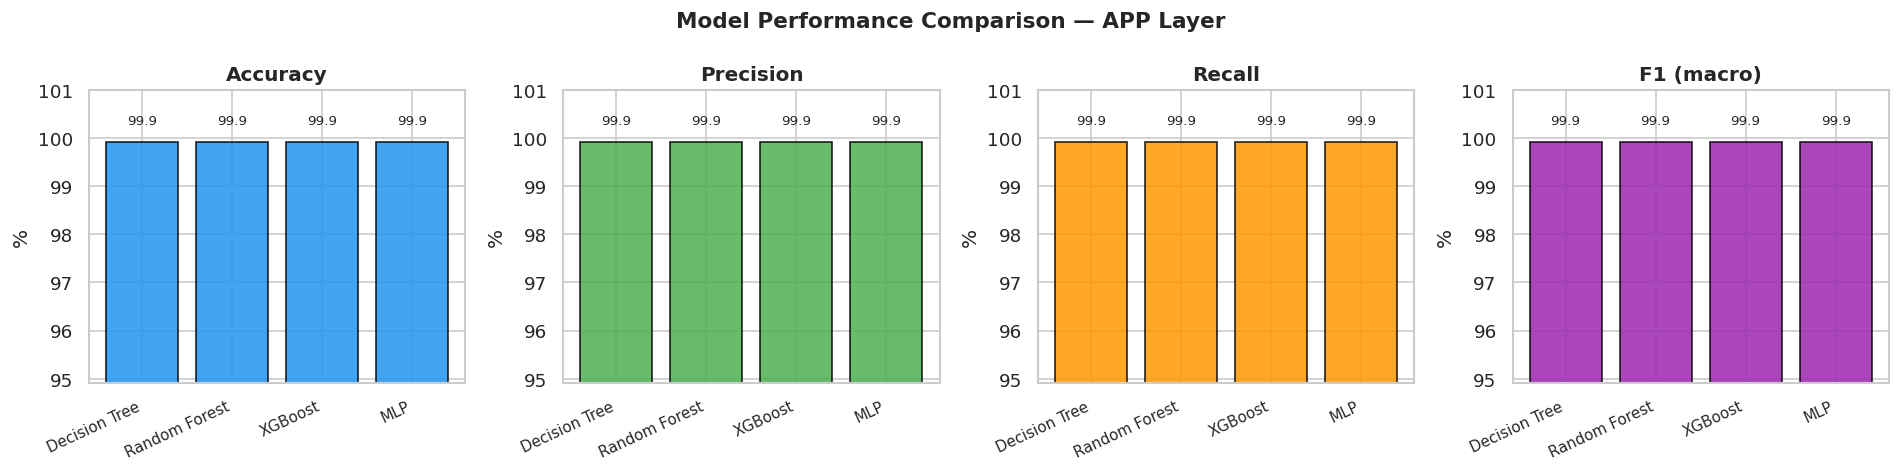

In [ ]:
# Summary table
metrics_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['model', 'y_pred']}
    for r in results.values()
], index=results.keys())

print('=== Model Comparison (%)===')
print(metrics_df.to_string())

# Bar chart comparison
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 (macro)']
colors  = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for ax, metric, color in zip(axes, metrics, colors):
    vals = metrics_df[metric]
    bars = ax.bar(vals.index, vals, color=color, edgecolor='black', alpha=0.85)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim([max(0, vals.min() - 5), 101])
    ax.set_xticklabels(vals.index, rotation=25, ha='right', fontsize=9)
    ax.set_ylabel('%')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Performance Comparison — APP Layer', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Detailed per-class report for the best model
best_model_name = metrics_df['F1 (macro)'].idxmax()
best_result = results[best_model_name]

print(f'Best model: {best_model_name}\n')
print(classification_report(
    y_test,
    best_result['y_pred'],
    target_names=le_app.classes_
))

Best model: Decision Tree

                                           precision    recall  f1-score   support

             cyberattack_ocpp16_doc_idtag       1.00      1.00      1.00       259
cyberattack_ocpp16_dos_flooding_heartbeat       1.00      1.00      1.00       259
   cyberattack_ocpp16_fdi_chargingprofile       1.00      1.00      1.00       259
   cyberattack_ocpp16_unauthorized_access       1.00      1.00      1.00       259
                                   normal       1.00      1.00      1.00       259

                                 accuracy                           1.00      1295
                                macro avg       1.00      1.00      1.00      1295
                             weighted avg       1.00      1.00      1.00      1295



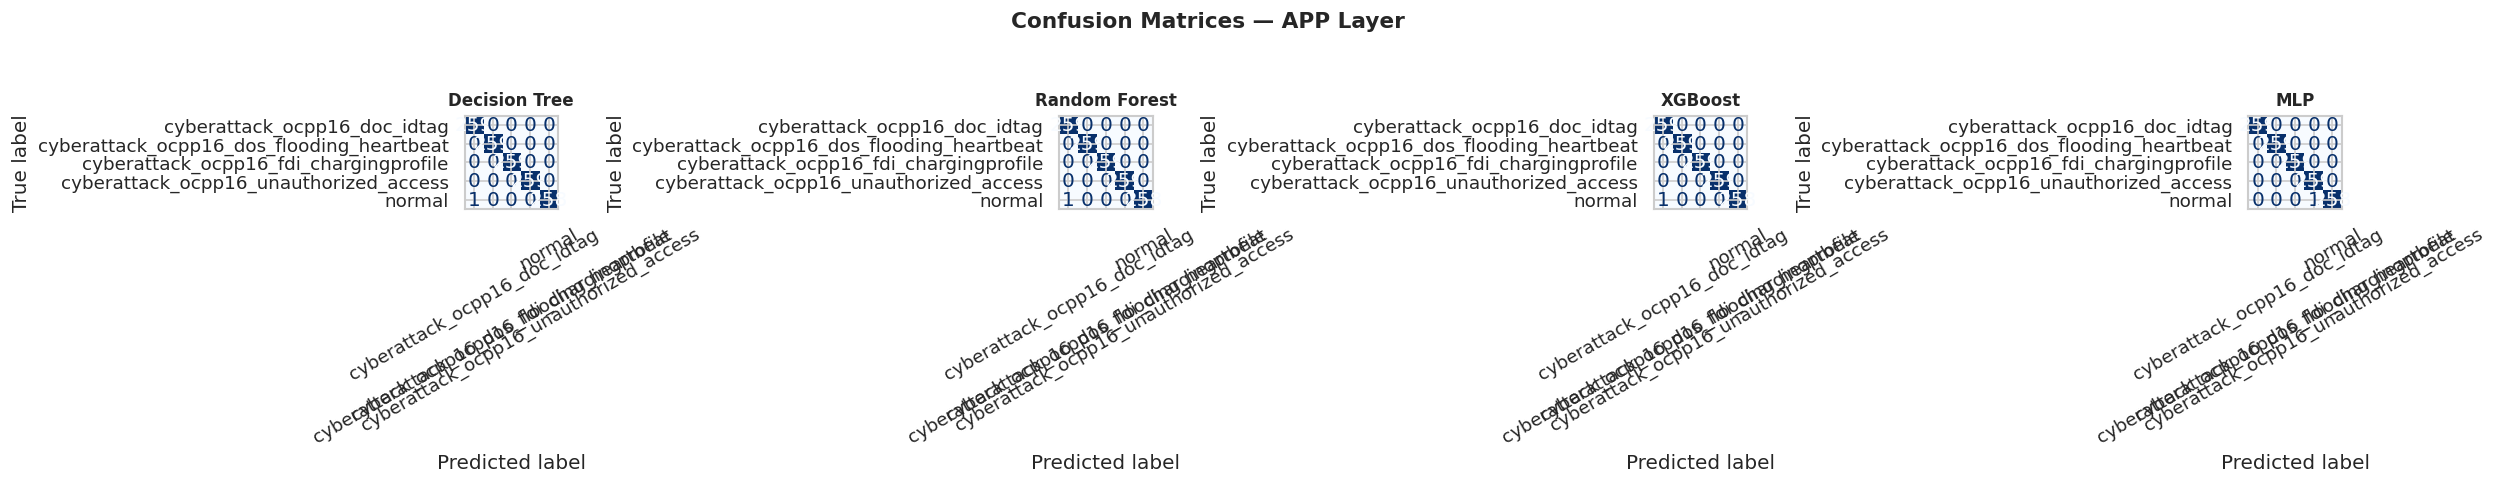

In [ ]:
# Confusion matrix for each model
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))

for ax, (name, result) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, result['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_app.classes_)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=30)
    ax.set_title(name, fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices — APP Layer', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# False Positive Rate (FPR) — critical for IDS
print('=== False Positive Rate per Model ===')
print('(Lower is better — false alarms in an IDS context)\n')

for name, result in results.items():
    cm = confusion_matrix(y_test, result['y_pred'])
    # FP = actual Normal classified as attack
    # Assuming class index 0 or whichever = 'Normal' / 'Benign'
    normal_idx = list(le_app.classes_).index('Normal') if 'Normal' in le_app.classes_ else 0
    FP = cm[:, normal_idx].sum() - cm[normal_idx, normal_idx]
    TN = cm[normal_idx, normal_idx]
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
    print(f'  {name:<20} FPR: {FPR:.4f} ({FPR*100:.2f}%)')

=== False Positive Rate per Model ===
(Lower is better — false alarms in an IDS context)

  Decision Tree        FPR: 0.0038 (0.38%)
  Random Forest        FPR: 0.0038 (0.38%)
  XGBoost              FPR: 0.0038 (0.38%)
  MLP                  FPR: 0.0000 (0.00%)


## Step 8 — (Optional) Feature Fusion: APP + TCP/IP Layers

Combining both layers can improve detection, especially for the **Heartbeat Flooding DoS** attack, which is primarily visible at the TCP/IP level.

**Two fusion strategies:**
- **Feature-level (early fusion):** Merge feature columns → train one model on the combined dataset
- **Decision-level (late fusion):** Train two models → combine their prediction probabilities

In [ ]:
# Load TCP/IP layer dataset (pre-split train/test)
try:
    df_tcp_train = pd.read_csv(TCP_TRAIN_PATH)
    df_tcp_test  = pd.read_csv(TCP_TEST_PATH)
    print(f'TCP/IP Layer Train shape: {df_tcp_train.shape}')
    print(f'TCP/IP Layer Test shape:  {df_tcp_test.shape}')
    TCP_AVAILABLE = True
except FileNotFoundError:
    print('TCP/IP layer CSVs not found. Skipping fusion steps.')
    print('Download Balanced_OCPP16_TCP-IP_Layer.zip from Zenodo to enable this.')
    TCP_AVAILABLE = False

In [ ]:
if TCP_AVAILABLE:
    print('Preprocessing TCP/IP Layer (train + test)...')
    X_tcp_train, X_tcp_test, y_tcp_train, y_tcp_test, le_tcp, _ = preprocess_split(
        df_tcp_train, df_tcp_test, LABEL_COL
    )

    # --- Feature-level fusion (early fusion) ---
    # Add prefix to TCP/IP columns to avoid name conflicts with APP layer
    X_tcp_train_pf = X_tcp_train.add_prefix('tcp_').reset_index(drop=True)
    X_tcp_test_pf  = X_tcp_test.add_prefix('tcp_').reset_index(drop=True)

    X_fus_train = pd.concat([X_train.reset_index(drop=True), X_tcp_train_pf], axis=1)
    X_fus_test  = pd.concat([X_test.reset_index(drop=True),  X_tcp_test_pf],  axis=1)
    y_fus_train = y_train.reset_index(drop=True)
    y_fus_test  = y_test.reset_index(drop=True)

    print(f'Fused train shape: {X_fus_train.shape}')
    print(f'Fused test shape:  {X_fus_test.shape}')

    # Scale fused features (fit on train only)
    scaler_fused = StandardScaler()
    X_fus_train_sc = scaler_fused.fit_transform(X_fus_train)
    X_fus_test_sc  = scaler_fused.transform(X_fus_test)

    # Train XGBoost on fused features
    xgb_fused = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss',
                               random_state=42, n_jobs=-1)
    xgb_fused.fit(X_fus_train_sc, y_fus_train)
    y_pred_fused = xgb_fused.predict(X_fus_test_sc)

    acc_fused = accuracy_score(y_fus_test, y_pred_fused)
    f1_fused  = f1_score(y_fus_test, y_pred_fused, average='macro')

    print(f'\nXGBoost on Fused (APP + TCP/IP):')
    print(f'   Accuracy:   {acc_fused:.4f}')
    print(f'   F1 (macro): {f1_fused:.4f}')
    print(f'\nCompare with XGBoost on APP only:')
    print(f"   Accuracy:   {results['XGBoost']['Accuracy']/100:.4f}")
    print(f"   F1 (macro): {results['XGBoost']['F1 (macro)']/100:.4f}")
else:
    print('ℹ️  Skipping fusion — TCP/IP layer not loaded.')

## Step 9 — Hyperparameter Tuning (Best Model)

GridSearchCV on the best-performing model. This can take a few minutes.

In [ ]:
print(f'Tuning: {best_model_name}\n')

# Parameter grids per model type
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    },
    'XGBoost': {
        'n_estimators': [100, 200],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.05, 0.1, 0.2]
    },
    'Decision Tree': {
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'criterion': ['gini', 'entropy']
    },
    'MLP': {
        'hidden_layer_sizes': [(64, 32), (128, 64), (256, 128)],
        'alpha': [0.0001, 0.001]
    }
}

base_model_map = {
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost':       XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'MLP':           MLPClassifier(max_iter=300, random_state=42, early_stopping=True)
}

if best_model_name in param_grids:
    grid_search = GridSearchCV(
        estimator=base_model_map[best_model_name],
        param_grid=param_grids[best_model_name],
        cv=5,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_train_sel_scaled, y_train)

    print(f'\nBest parameters: {grid_search.best_params_}')
    print(f'   Best CV F1 (macro): {grid_search.best_score_:.4f}')

    # Evaluate tuned model
    best_tuned = grid_search.best_estimator_
    y_pred_tuned = best_tuned.predict(X_test_sel_scaled)

    print(f'\n=== Tuned {best_model_name} — Test Set ===')
    print(classification_report(y_test, y_pred_tuned, target_names=le_app.classes_))
else:
    print(f'No param grid defined for {best_model_name}. Skipping tuning.')
    best_tuned = results[best_model_name]['model']

Tuning: Decision Tree

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}
   Best CV F1 (macro): 0.9993

=== Tuned Decision Tree — Test Set ===
                                           precision    recall  f1-score   support

             cyberattack_ocpp16_doc_idtag       1.00      1.00      1.00       259
cyberattack_ocpp16_dos_flooding_heartbeat       1.00      1.00      1.00       259
   cyberattack_ocpp16_fdi_chargingprofile       1.00      1.00      1.00       259
   cyberattack_ocpp16_unauthorized_access       1.00      1.00      1.00       259
                                   normal       1.00      1.00      1.00       259

                                 accuracy                           1.00      1295
                                macro avg       1.00      1.00      1.00      1295
                             weighted avg       1.00      1.00      1.00      1295



## Step 10 — Save the Best Model

In [ ]:
import joblib
from google.colab import files

# Save artifacts
joblib.dump(best_tuned,         'ocpp_ids_model.pkl')
joblib.dump(scaler_sel,         'ocpp_ids_scaler.pkl')
joblib.dump(le_app,             'ocpp_ids_label_encoder.pkl')
joblib.dump(top_feature_names,  'ocpp_ids_features.pkl')

print('Model artifacts saved:')
for f in ['ocpp_ids_model.pkl', 'ocpp_ids_scaler.pkl',
          'ocpp_ids_label_encoder.pkl', 'ocpp_ids_features.pkl']:
    size = os.path.getsize(f) / 1024
    print(f'   {f}  ({size:.1f} KB)')


Model artifacts saved:
   ocpp_ids_model.pkl  (2.4 KB)
   ocpp_ids_scaler.pkl  (2.5 KB)
   ocpp_ids_label_encoder.pkl  (0.6 KB)
   ocpp_ids_features.pkl  (1.0 KB)


In [ ]:
# Using saved model on new traffic

def predict_ocpp_traffic(raw_sample_df):
    """
    Predict the class of new OCPP traffic samples.
    raw_sample_df: pd.DataFrame with same columns as the training data (before scaling)
    """
    model_loaded   = joblib.load('ocpp_ids_model.pkl')
    scaler_loaded  = joblib.load('ocpp_ids_scaler.pkl')
    le_loaded      = joblib.load('ocpp_ids_label_encoder.pkl')
    features       = joblib.load('ocpp_ids_features.pkl')

    X_new = raw_sample_df[features]
    X_new_scaled = scaler_loaded.transform(X_new)
    y_pred = model_loaded.predict(X_new_scaled)
    y_prob = model_loaded.predict_proba(X_new_scaled)

    predictions = le_loaded.inverse_transform(y_pred)
    confidences = y_prob.max(axis=1)

    return pd.DataFrame({
        'Predicted Class': predictions,
        'Confidence': confidences
    })

# Example: predict on 5 test samples
sample = X_test[top_feature_names].iloc[:5]
output = predict_ocpp_traffic(sample)
output['True Label'] = le_app.inverse_transform(y_test.iloc[:5].values)
print('=== Inference Demo ===')
print(output.to_string(index=False))

=== Inference Demo ===
                          Predicted Class  Confidence                                True Label
cyberattack_ocpp16_dos_flooding_heartbeat         1.0 cyberattack_ocpp16_dos_flooding_heartbeat
   cyberattack_ocpp16_fdi_chargingprofile         1.0    cyberattack_ocpp16_fdi_chargingprofile
cyberattack_ocpp16_dos_flooding_heartbeat         1.0 cyberattack_ocpp16_dos_flooding_heartbeat
   cyberattack_ocpp16_unauthorized_access         1.0    cyberattack_ocpp16_unauthorized_access
   cyberattack_ocpp16_unauthorized_access         1.0    cyberattack_ocpp16_unauthorized_access


## Summary

| Step | What was done |
|------|---------------|
| 1–2  | Installed libraries and imported dependencies |
| 3    | Loaded `Balanced_OCPP16_APP_Layer` CSV |
| 4    | Dropped IDs/IPs, handled NaN/Inf, label encoded, scaled |
| 5    | Selected top features via Random Forest importance |
| 6    | Trained Decision Tree, Random Forest, XGBoost, MLP |
| 7    | Evaluated with Accuracy, F1, Precision, Recall, FPR |
| 8    | (Optional) Fused APP + TCP/IP feature sets |
| 9    | GridSearchCV hyperparameter tuning on best model |
| 10   | Saved model artifacts + inference demo |

### References
- Dalamagkas et al. (2025). *Federated Detection of Open Charge Point Protocol 1.6 Cyberattacks*. arXiv:2502.01569
- Dataset: https://zenodo.org/records/14887131